/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_84198/2911884358.py:49: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 11000)
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_84198/2911884358.py:49: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 11000)
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_84198/2911884358.py:49: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 11000)
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_84198/2911884358.py:49: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 11000)
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_84198/2911884358.py:49: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 11000)
/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000g

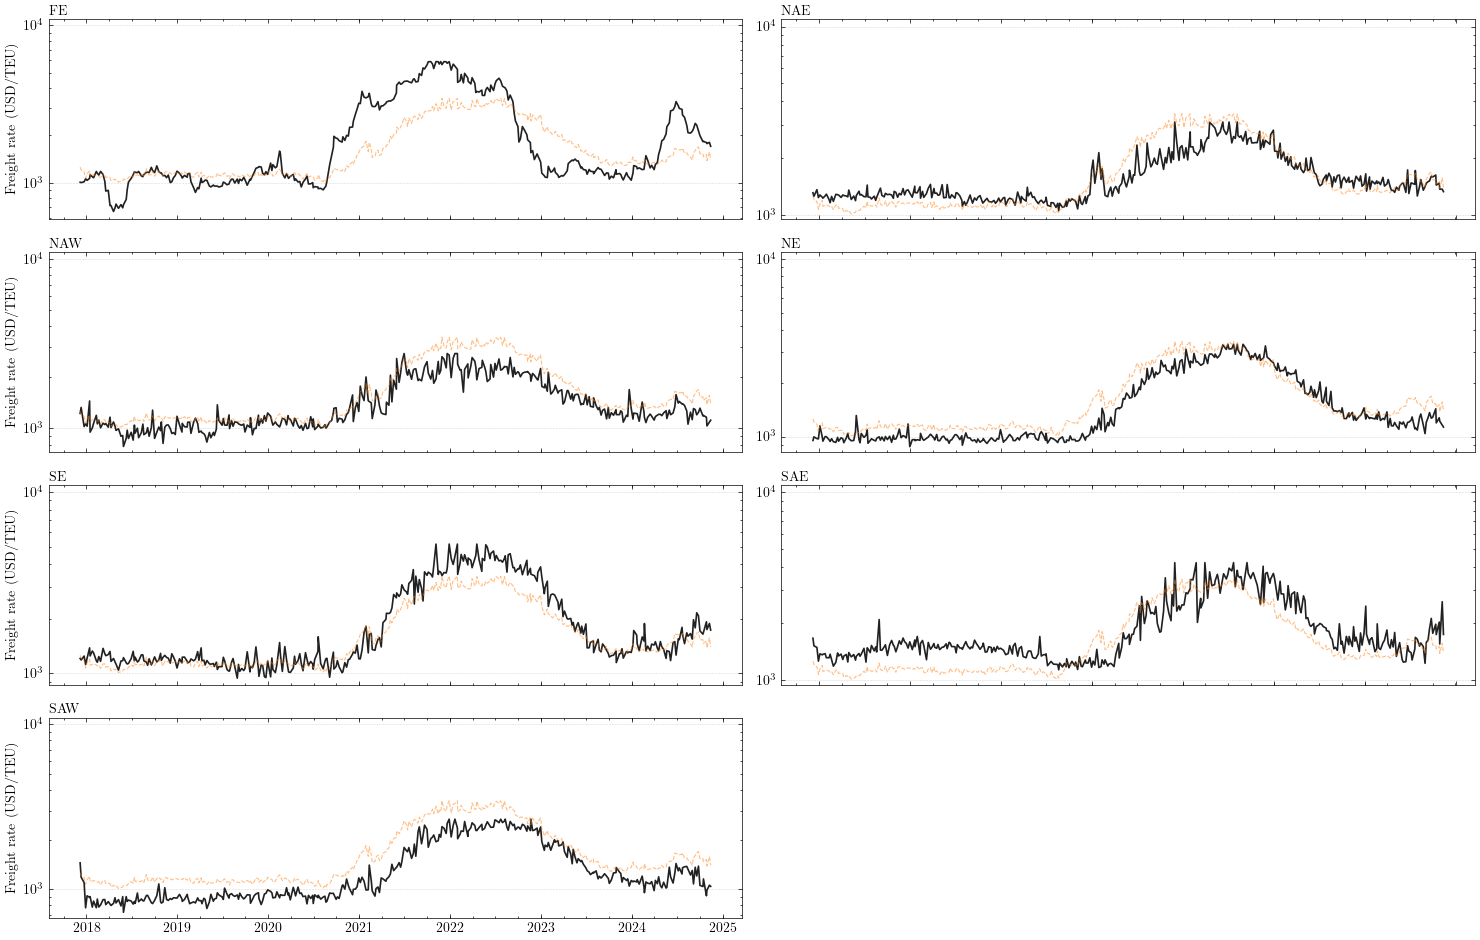

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scienceplots
plt.style.use('science')
# --- Load & preprocess -------------------------------------------------
# Adjust the path to your file as needed
df = pd.read_csv("weekly_chile_data.csv")

# FECHA is in "YYYY-WW" format (ISO year-week). Convert to a weekly date (Monday of that week).
df["date"] = pd.to_datetime(df["FECHA"])
df = df.sort_values("date")


# Route price columns we want in Figure 1
route_cols = ["FE", "NAE", "NAW", "NE", "SE", "SAE", "SAW"]
df["avg_route_price"] = df[route_cols].mean(axis=1)
df["avg_route_price"] = df["avg_route_price"].clip(upper=df["avg_route_price"].quantile(0.99))  # clip 99 percentile
# Optional: column to use as a faint background measure of weekly "scale"
volume_col = "CANTIDAD DE BULTO"

# --- Plot: small multiples of route prices -----------------------------
n_rows, n_cols = 4, 2   # 4x2 grid = 8 slots (we'll use 7 and hide 1)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True)
axes = axes.flatten()

for i, route in enumerate(route_cols):
    ax = axes[i]
    df[route] = df[route].clip(lower=0, upper=df[route].quantile(0.99)) #clip 99 percentile to avoid extreme outliers

    # Main line: freight price for this route
    ax.plot(df["date"], df[route], linewidth=1.2, color="#212122")
    ax.set_title(route, loc="left", fontsize=10, pad=3)
    ax.plot(
        df["date"],
        df["avg_route_price"],
        linewidth=0.8,
        linestyle="--",
        alpha=0.5,
        color="#ff7f0e",
    )
    ax.set_yscale("log")
    # Y label only on the left column to avoid clutter
    if i % n_cols == 0:
        ax.set_ylabel("Freight rate (USD/TEU)")

    # Light horizontal gridlines for readability
    ax.grid(True, axis="y", linewidth=0.4, linestyle="--", alpha=0.5)
    ax.set_ylim(0, 11000)

    # Optional: faint background line for total containers (scale/congestion)

# Hide any unused subplot (8th slot)
for j in range(len(route_cols), len(axes)):
    axes[j].set_visible(False)

# Shared x-axis formatting (years along the bottom row)
# Using the last axis just to set the locator/formatter (shared across all)
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout(rect=[0, 0, 1, 0.96])


plt.savefig("plots/route_prices_small_multiples.pdf", dpi=800)
plt.show()

In [3]:
df = df.sort_values("date")
df

,FECHA,RUTS_UNICOS_DIARIOS,CD,CFR,F,OTRO,CMA CGM,COSCO,EVERGREEN,HAMBURG SUD / COLUMBUS LINE,...,Close_pct_change_XSICFESE Index (L4),Close_pct_change_XSICNEFE Index (R2),Close_pct_change_XSICNESE Index (L2),Close_pct_change_XSICUENE Index (R1),Close_pct_change_XSICUWFE Index (L1),Close_pct_change_XSICNEUE Index (L3),Close_pct_change_BDIY Index (R3),year,week,date
0,2020-47,920,5473,1987,16162,1525,1504,1492,911,1451,...,0.005250,0.062853,0.009346,0.000000,0.017081,0.000000,0.071429,2020,47,2020-11-16
1,2020-48,792,3769,1941,14823,920,1471,1336,722,2149,...,0.093145,0.206217,0.012346,-0.011152,0.190840,0.001018,-0.026829,2020,48,2020-11-23
2,2020-49,1366,12543,4393,26208,3361,6023,3921,1100,4435,...,0.114872,0.021999,-0.004065,0.020677,0.010256,-0.001526,0.011696,2020,49,2020-11-30
3,2020-50,1557,13067,5728,34010,6514,7081,5157,1845,5663,...,0.081607,0.010455,0.011224,-0.001842,0.006345,0.000509,0.094137,2020,50,2020-12-07
4,2020-51,1475,12142,5467,30248,4039,5740,4103,1725,6764,...,0.156513,-0.003043,-0.003027,0.000000,0.000000,0.016802,0.030943,2020,51,2020-12-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,2024-41,3096,17050,5975,42239,7355,9066,4353,2085,317,...,-0.007287,-0.015345,-0.008711,-0.014060,-0.005706,0.012383,-0.128800,2024,41,2024-10-07
204,2024-42,3147,17061,5835,45495,6098,8945,5172,2967,0,...,-0.004794,0.000000,-0.001757,-0.005348,0.002869,-0.038347,-0.105330,2024,42,2024-10-14
205,2024-43,2424,14805,4889,30058,6530,7427,4328,2901,0,...,0.026946,-0.124675,0.015845,0.032258,0.004292,-0.015813,-0.022695,2024,43,2024-10-21
206,2024-44,2096,11866,4407,22201,4239,6895,2531,2175,0,...,-0.047493,0.053412,-0.020797,0.010417,-0.004274,-0.021656,0.084906,2024,44,2024-10-28
